# Housing Demand Prediction (Linear Regression Model)
### Predicting severe housing deprivation from immigration inflow

## API Calls

In [1]:
import requests
import itertools
import pandas as pd
import numpy as np

EUROSTAT_BASE = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"

def get_stat(url, params = {"format": "JSON", "lang": "en"}):
    """Fetch a Eurostat dataset and return raw JSON."""
    response = requests.get(url, params=params, timeout=90)
    response.raise_for_status()
    return response.json()

def eurostat_to_df(data):
    """Convert Eurostat JSON response to a flat DataFrame."""
    dims = {
        dim: list(info["category"]["label"].values())
        for dim, info in data["dimension"].items()
    }
    keys = list(itertools.product(*dims.values()))
    values = [data["value"].get(str(i)) for i in range(len(keys))]
    df = pd.DataFrame(keys, columns=dims.keys())
    df["value"] = values
    return df

# immigration: total citizenship, total sex, total age
immigration_raw = get_stat(
    f"{EUROSTAT_BASE}/tps00176"
)

# severe housing deprivation (target variable)
deprivation_raw = get_stat(
    f"{EUROSTAT_BASE}/sdg_11_11"
)

overburden_raw = get_stat(
    f"{EUROSTAT_BASE}/ilc_lvho07a"
)

df_immigration = eurostat_to_df(immigration_raw)
df_deprivation = eurostat_to_df(deprivation_raw)
df_overburden = eurostat_to_df(overburden_raw)

df_immigration.to_csv("immigration.csv", index=False)
df_deprivation.to_csv("deprivation.csv", index=False)
df_overburden.to_csv("overburden.csv", index=False)

print("immigration:", df_immigration.shape)
print("deprivation:", df_deprivation.shape)
print("overburden:", df_overburden.shape)

immigration: (1248, 9)
deprivation: (2451, 8)
overburden: (161874, 8)


## Initial Exploratory Data Analysis (EDA)

In [2]:
df_immigration = pd.read_csv("immigration.csv")
df_deprivation = pd.read_csv("deprivation.csv")
df_overburden = pd.read_csv("overburden.csv")

for label, df in [
    ("immigration", df_immigration),
    ("deprivation", df_deprivation),
    ("overburden", df_overburden)
]:
    print(f"=== {label} ===")
    print("  shape:",   df.shape)
    print("  columns:", df.columns.tolist())
    print("  nulls:\n", df.isnull().sum().to_string())
    print()

=== immigration ===
  shape: (1248, 9)
  columns: ['freq', 'citizen', 'agedef', 'age', 'unit', 'sex', 'geo', 'time', 'value']
  nulls:
 freq         0
citizen      0
agedef       0
age          0
unit         0
sex          0
geo          0
time         0
value      402

=== deprivation ===
  shape: (2451, 8)
  columns: ['freq', 'age', 'rskpovth', 'sex', 'unit', 'geo', 'time', 'value']
  nulls:
 freq          0
age           0
rskpovth      0
sex           0
unit          0
geo           0
time          0
value       525

=== overburden ===
  shape: (161874, 8)
  columns: ['freq', 'unit', 'rskpovth', 'age', 'sex', 'geo', 'time', 'value']
  nulls:
 freq            0
unit            0
rskpovth        0
age             0
sex             0
geo             0
time            0
value       35780



In [3]:
# inspect dimension values so we know how to filter each dataset
for label, df in [
    ("immigration", df_immigration),
    ("deprivation", df_deprivation),
    ("overburden", df_overburden)
]:
    print(f"=== {label} ===")
    for col in df.columns:
        if col not in ["value", "geo", "time"]:
            print(f"  {col}: {df[col].unique()[:8]}")
    print()

=== immigration ===
  freq: ['Annual']
  citizen: ['Total']
  agedef: ['Age reached during the year' 'Age in completed years']
  age: ['Total']
  unit: ['Number']
  sex: ['Total']

=== deprivation ===
  freq: ['Annual']
  age: ['Total']
  rskpovth: ['Total' 'Below 60%' 'Above 60%']
  sex: ['Total']
  unit: ['Percentage']

=== overburden ===
  freq: ['Annual']
  unit: ['Percentage']
  rskpovth: ['Below 60%' 'Above 60%' 'Total']
  age: ['Total' 'Less than 6 years' 'From 6 to 11 years' 'From 12 to 17 years'
 'From 15 to 19 years' 'From 15 to 24 years' 'From 15 to 29 years'
 'From 16 to 19 years']
  sex: ['Total' 'Males' 'Females']



## Clean Datasets

In [4]:
def clean_df(df, value_col):
    # standardise column names, drop nulls, remove EU aggregates
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
    )
    df = df.rename(columns={"value": value_col})
    df = df.dropna(subset=[value_col])
    if "time" in df.columns:
        df = df.rename(columns={"time": "year"})
    df = df[~df["geo"].str[:4].isin(["Euro", "EU27", "EU28"])]
    df["year"]    = df["year"].astype(int)
    df[value_col] = df[value_col].astype(float)
    return df

df_immigration_clean = clean_df(df_immigration, "immigration_count")
df_deprivation_clean = clean_df(df_deprivation, "deprivation_rate")
df_overburden_clean = clean_df(df_overburden, "overburden_rate")

# immigration: keep Total rows across all breakdown dimensions
for col in ["citizen", "sex", "age", "agedef", "unit"]:
    if col in df_immigration_clean.columns:
        vals = df_immigration_clean[col].unique()
        total_val = [v for v in vals if "total" in str(v).lower()]
        if total_val:
            df_immigration_clean = df_immigration_clean[
                df_immigration_clean[col] == total_val[0]
            ].copy()

# deprivation: keep Total quantile and Total household composition
for col in ["quantile", "hhcomp"]:
    if col in df_deprivation_clean.columns:
        vals = df_deprivation_clean[col].unique()
        print(f"{col} values:", vals)
        total_val = [v for v in vals if "total" in str(v).lower()]
        if total_val:
            df_deprivation_clean = df_deprivation_clean[
                df_deprivation_clean[col] == total_val[0]
            ].copy()


# check for year gaps
for label, df in [
    ("immigration", df_immigration_clean),
    ("deprivation", df_deprivation_clean),
    ("overburden", df_overburden_clean)
]:
    years = sorted(df["year"].unique())
    gaps  = [y for i, y in enumerate(years[1:], 1) if y - years[i-1] > 1]
    print(f"{label}: {years[0]}-{years[-1]}, gaps: {gaps if gaps else 'none'}")

df_immigration_clean = df_immigration_clean.drop(columns = ["age", "unit", "freq"])
df_immigration_clean = df_immigration_clean[df_immigration_clean["agedef"] == "Age in completed years"]

df_deprivation_clean = df_deprivation_clean.drop(columns = ["age", "unit", "freq"])

df_overburden_clean = df_overburden_clean.drop(columns = ["unit", "freq"])
df_overburden_clean = df_overburden_clean[df_overburden_clean["age"] == "Total"]
df_overburden_clean = df_overburden_clean[df_overburden_clean["sex"] == "Total"]

print("immigration clean:", df_immigration_clean.shape)
print("deprivation clean:", df_deprivation_clean.shape)
print("overburden clean:", df_overburden_clean.shape)

df_immigration_clean.to_csv("immigration_clean.csv", index=False)
df_deprivation_clean.to_csv("deprivation_clean.csv", index=False)
df_overburden_clean.to_csv("overburden_clean.csv", index=False)
print("Saved cleaned CSVs.")





immigration: 2013-2024, gaps: none
deprivation: 2003-2023, gaps: [np.int64(2023)]
overburden: 2003-2025, gaps: none
immigration clean: (411, 6)
deprivation clean: (1752, 5)
overburden clean: (2103, 6)
Saved cleaned CSVs.


## Data Visualizations

In [5]:
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

df_immigration_clean = pd.read_csv("immigration_clean.csv")
df_deprivation_clean = pd.read_csv("deprivation_clean.csv")

In [6]:
# plot 1: EU average deprivation rate over time
# tracks whether EU-wide housing conditions are improving

eu_dep = df_deprivation_clean.groupby("year")["deprivation_rate"].mean().reset_index()
eu_immig = df_immigration_clean.groupby("year")["immigration_count"].mean().reset_index()

fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=eu_dep["year"], y=eu_dep["deprivation_rate"],
    name="Deprivation rate (%)", line=dict(color="#30D836"), mode="lines+markers"
))
fig1.update_layout(
    title="EU average severe housing deprivation rate over time",
    xaxis_title="Year", yaxis_title="Rate (%)"
)
fig1.show()
fig1.write_html('eu_avg_housing_deprivation.html', full_html=False, include_plotlyjs='cdn')

In [7]:
# plot 2: severe housing deprivation by country (latest year)

latest_dep = (
    df_deprivation_clean
    .sort_values("year", ascending=False)
    .groupby("geo", as_index=False)["deprivation_rate"].first()
    .sort_values("deprivation_rate")
)

fig2 = px.bar(
    latest_dep, x="deprivation_rate", y="geo", orientation="h",
    title="Severe housing deprivation rate by country (latest year)",
    labels={"deprivation_rate": "Deprivation rate (%)", "geo": ""},
    color_discrete_sequence=["#378ADD"]
)
fig2.show()
fig2.write_html('housing_deprivation_by_country.html', full_html=False, include_plotlyjs='cdn')

In [8]:
# plot 3: immigration inflow by country (latest year)

latest_immig = (
    df_immigration_clean
    .sort_values("year", ascending=False)
    .groupby("geo", as_index=False)["immigration_count"].first()
    .sort_values("immigration_count")
)

fig3 = px.bar(
    latest_immig, x="immigration_count", y="geo", orientation="h",
    title="Immigration inflow by country (latest year)",
    labels={"immigration_count": "Number of immigrants", "geo": ""}, color_discrete_sequence=["#ED9F0F"]
)
fig3.show()

In [9]:
# plot 4: deprivation over time for top 5 worst countries

top5 = latest_dep.sort_values("deprivation_rate", ascending=False).head(5)["geo"].tolist()
dep_top5 = df_deprivation_clean[df_deprivation_clean["geo"].isin(top5)]

fig4 = px.line(
    dep_top5, x="year", y="deprivation_rate", color="geo", markers=True,
    title="Severe housing deprivation over time - 5 highest-deprivation countries",
    labels={"deprivation_rate": "Deprivation rate (%)", "year": "Year", "geo": "Country"}
)
fig4.show()

## Aggregate, Engineer Features, and Merge

In [25]:
'''
def aggregate_to_country_year(df, value_col):
    """Mean-aggregate all extra dimensions down to geo x year."""
    return df.groupby(["geo", "year"], as_index=False)[value_col].mean()

agg_immigration = aggregate_to_country_year(df_immigration_clean, "immigration_count")
agg_deprivation = aggregate_to_country_year(df_deprivation_clean, "deprivation_rate")

# merge on country and year, starting from the target
merged = (
    agg_deprivation
    .merge(agg_immigration, on=["geo", "year"], how="inner")
)
merged = merged.dropna()
print(f"Merged: {merged.shape[0]} rows, {merged['geo'].nunique()} countries")
print(f"Years: {merged['year'].min()} - {merged['year'].max()}")
merged.head()
'''

# drop constant dimension columns (all filtered to Total already)

df_deprivation_clean = df_deprivation_clean.drop(columns=["hhcomp"], errors="ignore")
df_deprivation_clean = df_deprivation_clean.drop(columns=["quantile"], errors="ignore")

# merge: start from target, join features on geo + year
merged = df_deprivation_clean.merge(df_immigration_clean, on=["geo", "year", "sex"])
merged = merged.merge(df_overburden_clean, on=["geo", "year", "rskpovth"])

merged = merged.dropna()
print(f"Merged: {merged.shape[0]} rows, {merged['geo'].nunique()} countries")
merged.to_csv("merged_linreg.csv", index=False)


Merged: 870 rows, 33 countries


In [26]:
# feature engineering

# log-transform immigration count (fixes right skew)
merged["log_immigration"] = np.log1p(merged["immigration_count"])

# 1-year lagged immigration (last year's inflow predicts this year's deprivation)
merged = merged.sort_values(["geo", "year"])
merged["immigration_lag1"] = merged.groupby("geo")["log_immigration"].shift(1)

# drop rows where lag is NaN
merged = merged.dropna(subset=["immigration_lag1"])
print(f"After lag: {merged.shape[0]} rows, {merged['geo'].nunique()} countries")
merged.to_csv("merged_linreg.csv", index=False)
'''
country_dummies = pd.get_dummies(merged["geo"], prefix="country", drop_first=True)
merged_with_dummies = pd.concat([
    merged.reset_index(drop=True),
    country_dummies.reset_index(drop=True)
], axis=1)

print(f"Shape with country dummies: {merged_with_dummies.shape}")
merged_with_dummies.to_csv("merged_linreg.csv", index=False)
merged_with_dummies.head()
'''

After lag: 837 rows, 33 countries


'\ncountry_dummies = pd.get_dummies(merged["geo"], prefix="country", drop_first=True)\nmerged_with_dummies = pd.concat([\n    merged.reset_index(drop=True),\n    country_dummies.reset_index(drop=True)\n], axis=1)\n\nprint(f"Shape with country dummies: {merged_with_dummies.shape}")\nmerged_with_dummies.to_csv("merged_linreg.csv", index=False)\nmerged_with_dummies.head()\n'

## Linear Regression Model

**Features (X):**
- immigration_lag1: log immigration from the previous year
- year: captures overall EU trend over time
- Country dummies: one per country (minus one reference country); these capture each country's baseline deprivation level

**Target (y):** deprivation_rate: real measured Eurostat outcome, not derived from inputs.

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("merged_linreg.csv")

continuous_cols = ["immigration_lag1", "overburden_rate"]

dummy_cols = [c for c in df.columns if c.startswith("country_")]

target_col = "deprivation_rate"

X_continuous = df[continuous_cols].to_numpy()
X_dummies    = df[dummy_cols].to_numpy().astype(float)
y            = df[target_col].to_numpy()

(
    X_cont_train, X_cont_test,
    X_dum_train,  X_dum_test,
    y_train,      y_test
) = train_test_split(
    X_continuous, X_dummies, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_cont_train_scaled = scaler.fit_transform(X_cont_train)
X_cont_test_scaled  = scaler.transform(X_cont_test)

X_train = np.hstack([X_cont_train_scaled, X_dum_train])
X_test  = np.hstack([X_cont_test_scaled,  X_dum_test])

print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")
print(f"Features: {X_train.shape[1]} ({len(continuous_cols)} continuous + {len(dummy_cols)} country dummies)")

Train: 585 rows, Test: 252 rows
Features: 2 (2 continuous + 0 country dummies)


In [28]:
def my_linear_regression(X_train, y_train, X_test):
    """
    Linear regression using the closed-form normal equation.
    Solves: w = (X^T X)^{-1} X^T y

    Args:
        X_train: numpy array (n_samples, n_features)
        y_train: numpy array (n_samples,)
        X_test:  numpy array (m_samples, n_features)

    Returns:
        y_pred:  numpy array (m_samples,) - predicted deprivation rates
        weights: numpy array (n_features + 1,) - [intercept, coef1, coef2, ...]
    """
    n = X_train.shape[0]
    X_b = np.column_stack([np.ones(n), X_train])

    weights = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y_train

    m = X_test.shape[0]
    X_test_b = np.column_stack([np.ones(m), X_test])
    y_pred = X_test_b @ weights

    return y_pred, weights


y_pred, weights = my_linear_regression(X_train, y_train, X_test)

print("Continuous feature coefficients (after scaling):")
labels = ["intercept"] + continuous_cols
for label, w in zip(labels, weights[:len(labels)]):
    print(f"  {label:25s}: {w:.4f}")

Continuous feature coefficients (after scaling):
  intercept                : 6.7443
  immigration_lag1         : -1.8509
  overburden_rate          : 3.6087


In [29]:
# success metrics
mse  = mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"R2:   {r2:.4f}")

MSE:  40.2561
R2:   0.2542


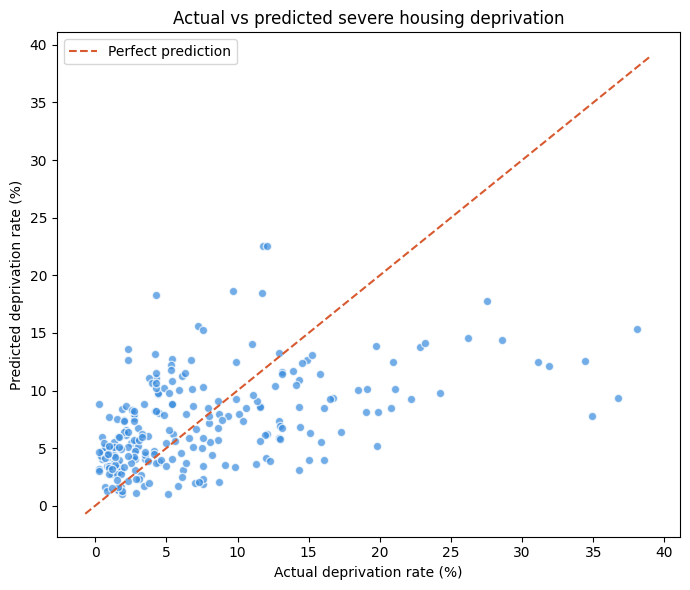

In [30]:
# plot 5: actual vs predicted deprivation rate

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.7, color="#378ADD", edgecolors="white")
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
ax.plot(lims, lims, "--", color="#D85A30", label="Perfect prediction")
ax.set_xlabel("Actual deprivation rate (%)")
ax.set_ylabel("Predicted deprivation rate (%)")
ax.set_title("Actual vs predicted severe housing deprivation")
ax.legend()
plt.tight_layout()
plt.show()

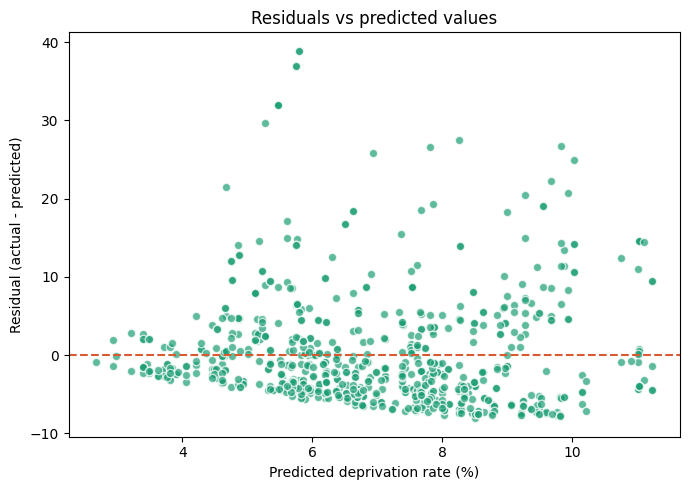

In [16]:
# plot 6: residuals

residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred, residuals, alpha=0.7, color="#1D9E75", edgecolors="white")
ax.axhline(0, color="#D85A30", linestyle="--")
ax.set_xlabel("Predicted deprivation rate (%)")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residuals vs predicted values")
plt.tight_layout()
plt.show()

## Interpret and Apply the Model

The coefficients tell us:
- immigration_lag1: whether last year's immigration inflow is associated with higher or lower deprivation this year
- year: whether deprivation is generally improving or worsening across Europe over time
- Country dummies: the baseline deprivation level for each country relative to the reference country

In [17]:
# predict deprivation for the most recent year per country

latest = (
    df.sort_values("year", ascending=False)
    .groupby("geo", as_index=False)
    .first()
)

X_latest_cont = scaler.transform(latest[continuous_cols].to_numpy())
X_latest_dum  = latest[dummy_cols].to_numpy().astype(float)
X_latest      = np.hstack([X_latest_cont, X_latest_dum])

n_latest   = X_latest.shape[0]
X_latest_b = np.column_stack([np.ones(n_latest), X_latest])
latest["predicted_deprivation"] = X_latest_b @ weights

result = (
    latest[["geo", "year", "deprivation_rate", "predicted_deprivation"]]
    .sort_values("predicted_deprivation", ascending=False)
)
print("Countries ranked by predicted deprivation (highest = most need for ESF+ funding):")
print(result.to_string(index=False))

Countries ranked by predicted deprivation (highest = most need for ESF+ funding):
            geo  year  deprivation_rate  predicted_deprivation
North Macedonia  2020              23.2              10.747911
       Slovakia  2023               2.1               9.693572
        Iceland  2020               3.4               9.234073
         Latvia  2023              16.5               8.476659
     Montenegro  2023              12.7               8.277678
     Luxembourg  2023               2.2               8.020185
         Cyprus  2023               1.2               8.000267
        Estonia  2023               2.9               7.819182
       Slovenia  2023               3.5               7.504060
          Malta  2023               0.5               7.229649
       Bulgaria  2023               3.5               6.857983
      Lithuania  2023               4.3               6.656950
        Croatia  2023               6.0               6.606911
        Finland  2023               

In [18]:
# plot 7: predicted deprivation by country

fig7 = px.bar(
    result.sort_values("predicted_deprivation"),
    x="predicted_deprivation", y="geo", orientation="h",
    title="Predicted severe housing deprivation by country",
    labels={"predicted_deprivation": "Predicted deprivation rate (%)", "geo": ""}, color_discrete_sequence=["#ED0F52"]
)
fig7.show()
fig7.write_html('predicted_housing_deprivation_by_country.html', full_html=False, include_plotlyjs='cdn')